# DICE-Net: AD vs CN EEG Binary Classification

## Experiment Overview

**Task:** Binary classification of Alzheimer's Disease (AD) vs Cognitively Normal (CN) subjects using resting-state EEG recordings.

**Dataset:** Miltiadous et al. (2023) — 88 total subjects, 19-channel scalp EEG at 500 Hz.
- AD: 25 labeled subjects
- CN: 13 labeled subjects
- FTD: 16 labeled subjects (excluded from this task)
- 15 CN .npy files without labels in CSV (challenge test data — excluded from training)

**Model:** DICE-Net (Dual-branch Independent Convolutional Encoder with Transformer)
- Branch 1: Relative Band Power (RBP) features
- Branch 2: Spectral Coherence Connectivity (SCC) features
- Each branch: Conv1D → Positional Embedding + [CLS] Token → Transformer Encoder
- Concatenate branch outputs → Feed-forward classifier

**Evaluation:** Leave-One-Subject-Out (LOSO) cross-validation
- 38 outer folds (one per subject)
- Inner ~80/20 train/validation split by subject
- Subject-level prediction via window aggregation (average probability + majority vote)
- Metrics: Accuracy, F1, Precision, Recall, Specificity, ROC-AUC, Confusion Matrix

**Key Methodology Safeguards:**
- All splits are by SUBJECT — no window-level leakage
- Normalization fitted on training subjects only per fold
- Class weights computed from training fold only
- Early stopping on validation loss
- Features cached to the configured cache directory to avoid re-extraction


## 1. Colab Setup

In [40]:
# Install required packages (Colab has most, but PyWavelets may be missing)
!pip install -q PyWavelets
print("Packages ready.")

Packages ready.


## 2. Imports and Reproducibility

In [41]:
import os
import copy
import random
import warnings
import time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from scipy.signal import welch, resample
import pywt

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ---------- Reproducibility ----------
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Global seed set to {SEED}")


Global seed set to 42


## 3. Path Configuration

In [42]:
# Running locally — data is in ./training/
print("Using local ./training/ paths.")

Using local ./training/ paths.


In [43]:
# ============================================================
# CONFIGURATION
# ============================================================
CONFIG = {
    # ----- Paths (local) -----
    'DATA_DIR':       './training',
    'AD_DIR':         './training/AD',
    'CN_DIR':         './training/CN',
    'LABEL_CSV_PATH': './training/train_label_mapping.csv',
    'CACHE_DIR':      './training/cache',
    'CHECKPOINT_DIR': './training/checkpoints',
    'RESULTS_DIR':    './training/results',

    # ----- Signal parameters -----
    'ORIG_SFREQ':  500,
    'TARGET_SFREQ': 128,
    'WINDOW_SEC':   30,
    'OVERLAP_SEC':  15,
    'N_CHANNELS':   19,
    'N_BANDS':       5,
    'TIME_STEPS':   30,

    # ----- DICE-Net architecture -----
    'D_MODEL':              64,
    'N_HEADS':               4,
    'N_TRANSFORMER_LAYERS':  2,
    'DROPOUT':             0.3,

    # ----- Training -----
    'BATCH_SIZE':    32,
    'LR':           1e-3,
    'WEIGHT_DECAY': 1e-2,
    'EPOCHS':       100,
    'PATIENCE':      20,
    'SEED':          42,

    # ----- Experiment mode -----
    'QUICK_SMOKE_TEST':    False,   # Set False for full LOSO run
    'SMOKE_TEST_FOLDS':    5,
    'SMOKE_TEST_EPOCHS':   15,
}

# Validate paths exist
for key in ['AD_DIR', 'CN_DIR', 'LABEL_CSV_PATH']:
    path = CONFIG[key]
    ok = os.path.exists(path)
    status = 'OK' if ok else 'MISSING'
    print(f"  [{status}] {key}: {path}")
    if not ok:
        raise FileNotFoundError(f"{key} not found at {path}. Did you upload the files?")

# Create output directories
for d in ['CACHE_DIR', 'CHECKPOINT_DIR', 'RESULTS_DIR']:
    os.makedirs(CONFIG[d], exist_ok=True)
    print(f"  {d}: {CONFIG[d]}")

print("\nConfiguration loaded.")

  [OK] AD_DIR: ./training/AD
  [OK] CN_DIR: ./training/CN
  [OK] LABEL_CSV_PATH: ./training/train_label_mapping.csv
  CACHE_DIR: ./training/cache
  CHECKPOINT_DIR: ./training/checkpoints
  RESULTS_DIR: ./training/results

Configuration loaded.


### Runtime Check

In [44]:
# Verify GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU:    {torch.cuda.get_device_name(0)}")
    print(f"VRAM:   {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Training will be very slow.")
    print("Go to Runtime > Change runtime type > GPU")


Device: cpu
Go to Runtime > Change runtime type > GPU


## 4. Load Label CSV and Build AD vs CN Subject Table

The CSV (`train_label_mapping.csv`) is the **single source of truth** for labels.
- `A` → AD → 1
- `C` / `CN` → CN → 0
- `F` / `FTD` → excluded


In [45]:
# Load label CSV
label_df = pd.read_csv(CONFIG['LABEL_CSV_PATH'])
print(f"Raw CSV shape: {label_df.shape}")
print(f"Columns: {list(label_df.columns)}")
print(f"\nLabel distribution:\n{label_df['label'].value_counts().to_string()}")

# Normalize subject IDs to int
label_df['subject_id'] = label_df['anonymized_id'].astype(str).str.strip().astype(int)

# Count FTD before excluding
n_ftd = label_df[label_df['label'].isin(['F', 'FTD'])].shape[0]

# Filter: keep only AD (A) and CN (C/CN)
task_df = label_df[label_df['label'].isin(['A', 'C', 'CN'])].copy()

# Binary label: A -> 1, C/CN -> 0
task_df['binary_label'] = task_df['label'].map(lambda x: 1 if x == 'A' else 0)

print(f"\n--- AD vs CN Task ---")
print(f"AD (label=1): {(task_df['binary_label'] == 1).sum()} subjects")
print(f"CN (label=0): {(task_df['binary_label'] == 0).sum()} subjects")
print(f"Excluded FTD: {n_ftd} subjects")
print(f"Total for task: {len(task_df)} subjects")

task_df.head(10)


Raw CSV shape: (54, 2)
Columns: ['anonymized_id', 'label']

Label distribution:
label
A    25
F    16
C    13

--- AD vs CN Task ---
AD (label=1): 25 subjects
CN (label=0): 13 subjects
Excluded FTD: 16 subjects
Total for task: 38 subjects


,anonymized_id,label,subject_id,binary_label
1,3,A,3,1
2,4,A,4,1
3,8,A,8,1
4,9,A,9,1
5,10,C,10,0
10,18,A,18,1
11,23,C,23,0
12,24,C,24,0
13,27,A,27,1
14,28,A,28,1


## 5. Discover and Match Raw EEG Files

The notebook looks in:
- `/content/AD/` — Alzheimer's `.npy` files
- `/content/CN/` — Control Normal `.npy` files

The label CSV (`/content/train_label_mapping.csv`) is the source of truth for class labels.

- **Training / validation / LOSO test folds** use only subjects in both the CSV and these folders.
- `.npy` files not in the CSV are excluded from training.

In [46]:
# Discover .npy files only from the expected labeled EEG folders
search_roots = {
    'AD': CONFIG['AD_DIR'],
    'CN': CONFIG['CN_DIR'],
}

npy_files = {}
folder_source = {}

for folder_name, folder_path in search_roots.items():
    assert os.path.isdir(folder_path), f"Expected folder not found: {folder_path}"

    for fname in sorted(os.listdir(folder_path)):
        if not fname.endswith('.npy'):
            continue

        try:
            subj_id = int(os.path.splitext(fname)[0])
        except ValueError:
            print(f"  WARNING: Could not parse subject ID from {folder_path}/{fname}, skipping.")
            continue

        full_path = os.path.join(folder_path, fname)
        if subj_id in npy_files:
            raise ValueError(
                f"Duplicate subject ID {subj_id} found in both {npy_files[subj_id]} and {full_path}"
            )

        npy_files[subj_id] = full_path
        folder_source[subj_id] = folder_name

print(f"Discovered {len(npy_files)} .npy files from AD/CN folders.")
print(f"  AD folder files: {sum(1 for v in folder_source.values() if v == 'AD')}")
print(f"  CN folder files: {sum(1 for v in folder_source.values() if v == 'CN')}")

# Match CSV subjects to .npy files
task_df['npy_path'] = task_df['subject_id'].map(npy_files)
task_df['folder_source'] = task_df['subject_id'].map(folder_source)

matched_df = task_df.dropna(subset=['npy_path']).copy()
unmatched_csv = task_df[task_df['npy_path'].isna()].copy()

# Files without labels in CSV are kept separate for inference only
csv_subject_ids = set(label_df['subject_id'].unique())
unlabeled_files = {sid: path for sid, path in npy_files.items() if sid not in csv_subject_ids}

print(f"\n--- Matching Summary ---")
print(f"Total labeled rows (AD+CN): {len(task_df)}")
print(f"Matched EEG files:          {len(matched_df)}")
print(f"Unmatched CSV subjects:     {len(unmatched_csv)}")
if len(unmatched_csv) > 0:
    print(f"  IDs: {sorted(unmatched_csv['subject_id'].tolist())}")
print(f"Unlabeled .npy files:       {len(unlabeled_files)}")
if len(unlabeled_files) > 0:
    print(f"  IDs: {sorted(unlabeled_files.keys())}")

# Optional sanity check: compare folder name with CSV label for matched subjects
folder_label_mismatch = matched_df[
    ((matched_df['label'] == 'A') & (matched_df['folder_source'] != 'AD')) |
    (matched_df['label'].isin(['C', 'CN']) & (matched_df['folder_source'] != 'CN'))
]
if len(folder_label_mismatch) > 0:
    raise ValueError(
        "Folder/label mismatch detected for subjects: "
        f"{folder_label_mismatch[['subject_id', 'label', 'folder_source']].to_dict('records')}"
    )

# CRITICAL: Fail loudly if dataset is malformed
assert len(matched_df) > 0, "ERROR: No subjects matched between CSV and .npy files!"
assert (matched_df['binary_label'] == 1).sum() >= 1, "ERROR: No AD subjects found!"
assert (matched_df['binary_label'] == 0).sum() >= 1, "ERROR: No CN subjects found!"
assert len(unmatched_csv) == 0, (
    f"ERROR: {len(unmatched_csv)} CSV subjects have no matching .npy file! "
    f"IDs: {sorted(unmatched_csv['subject_id'].tolist())}"
)

print(f"\nAll {len(matched_df)} labeled subjects matched successfully.")
print("Only matched_df subjects will enter LOSO train/validation/test folds.")
print("Unlabeled files are excluded from training and reserved for inference only.")

matched_df = matched_df.sort_values('subject_id').reset_index(drop=True)
matched_df[['subject_id', 'label', 'binary_label', 'folder_source', 'npy_path']].head(10)

Discovered 53 .npy files from AD/CN folders.
  AD folder files: 25
  CN folder files: 28

--- Matching Summary ---
Total labeled rows (AD+CN): 38
Matched EEG files:          38
Unmatched CSV subjects:     0
Unlabeled .npy files:       15
  IDs: [5, 6, 17, 20, 22, 25, 26, 33, 35, 36, 45, 47, 60, 67, 87]

All 38 labeled subjects matched successfully.
Only matched_df subjects will enter LOSO train/validation/test folds.
Unlabeled files are excluded from training and reserved for inference only.


,subject_id,label,binary_label,folder_source,npy_path
0,3,A,1,AD,./training/AD/3.npy
1,4,A,1,AD,./training/AD/4.npy
2,8,A,1,AD,./training/AD/8.npy
3,9,A,1,AD,./training/AD/9.npy
4,10,C,0,CN,./training/CN/10.npy
5,18,A,1,AD,./training/AD/18.npy
6,23,C,0,CN,./training/CN/23.npy
7,24,C,0,CN,./training/CN/24.npy
8,27,A,1,AD,./training/AD/27.npy
9,28,A,1,AD,./training/AD/28.npy


## 6. Sanity Checks and Exploratory Summaries

In [47]:
# Check shapes of a few EEG recordings
print("Sample EEG shapes:")
for _, row in matched_df.head(5).iterrows():
    data = np.load(row['npy_path'], allow_pickle=True)
    duration_s = data.shape[1] / CONFIG['ORIG_SFREQ']
    n_windows = max(0, (data.shape[1] - CONFIG['WINDOW_SEC'] * CONFIG['ORIG_SFREQ']) //
                    (CONFIG['OVERLAP_SEC'] * CONFIG['ORIG_SFREQ']) + 1)
    print(f"  Subject {row['subject_id']:3d} | Label: {row['label']} | "
          f"Shape: {data.shape} | Duration: {duration_s:.1f}s | "
          f"~{n_windows} windows @ 500Hz")

# Summary table
summary = matched_df.groupby('binary_label').agg(
    count=('subject_id', 'count'),
    subjects=('subject_id', lambda x: sorted(x.tolist()))
).reset_index()
summary['class'] = summary['binary_label'].map({0: 'CN', 1: 'AD'})
print(f"\n--- Class Summary ---")
for _, r in summary.iterrows():
    print(f"  {r['class']} (label={r['binary_label']}): {r['count']} subjects")
    print(f"    IDs: {r['subjects']}")


Sample EEG shapes:
  Subject   3 | Label: A | Shape: (19, 119608) | Duration: 239.2s | ~14 windows @ 500Hz
  Subject   4 | Label: A | Shape: (19, 80947) | Duration: 161.9s | ~9 windows @ 500Hz
  Subject   8 | Label: A | Shape: (19, 102116) | Duration: 204.2s | ~12 windows @ 500Hz
  Subject   9 | Label: A | Shape: (19, 106847) | Duration: 213.7s | ~13 windows @ 500Hz
  Subject  10 | Label: C | Shape: (19, 112845) | Duration: 225.7s | ~14 windows @ 500Hz

--- Class Summary ---
  CN (label=0): 13 subjects
    IDs: [10, 23, 24, 30, 39, 42, 48, 52, 64, 69, 75, 84, 85]
  AD (label=1): 25 subjects
    IDs: [3, 4, 8, 9, 18, 27, 28, 32, 34, 40, 44, 46, 50, 51, 53, 55, 56, 61, 70, 73, 76, 78, 81, 82, 86]


## 7. Feature Extraction: Windowing, Downsampling, RBP & SCC

**Pipeline per subject:**
1. Load raw EEG (19 channels, 500 Hz)
2. Downsample to 128 Hz
3. Slide 30-second windows with 15-second overlap
4. Extract **RBP** (Relative Band Power) and **SCC** (Spectral Coherence Connectivity) per window

Each window produces:
- RBP: `(30, 5, 19)` — 30 sub-segments × 5 frequency bands × 19 channels
- SCC: `(30, 5, 19)` — same shape

**Frequency bands:** δ (0.5–4), θ (4–8), α (8–13), β (13–25), γ (25–45) Hz

> The `extract_features` function below is adapted from the challenge starter code.


In [48]:
def extract_features(eeg_data, sfreq, target_time_steps=30):
    '''
    Extracts RBP (Welch PSD) and SCC (CWT-based coherence) from a single EEG epoch.

    Args:
        eeg_data: (n_channels, n_points) — a single window of EEG data
        sfreq: sampling frequency (e.g. 128 Hz after downsampling)
        target_time_steps: number of 1-second sub-segments (30 for a 30s window)

    Returns:
        rbp: (target_time_steps, 5, n_channels) — relative band power
        scc: (target_time_steps, 5, n_channels) — spectral coherence connectivity
    '''
    n_channels, n_points = eeg_data.shape
    segment_len = int(n_points / target_time_steps)

    # ----- 1. Relative Band Power (RBP) -----
    bands = [(0.5, 4), (4, 8), (8, 13), (13, 25), (25, 45)]
    rbp_features = np.zeros((target_time_steps, 5, n_channels))

    for t in range(target_time_steps):
        start = t * segment_len
        end = start + segment_len
        segment = eeg_data[:, start:end]
        freqs, psd = welch(segment, fs=sfreq, nperseg=segment_len, axis=1)
        total_power = np.sum(psd, axis=1, keepdims=True)
        total_power[total_power == 0] = 1e-10
        for b_idx, (fmin, fmax) in enumerate(bands):
            idx = np.logical_and(freqs >= fmin, freqs <= fmax)
            band_power = np.sum(psd[:, idx], axis=1)
            rbp_features[t, b_idx, :] = band_power / total_power.flatten()

    # ----- 2. Spectral Coherence Connectivity (SCC) via CWT -----
    morlet_freqs = np.array([2, 6, 10, 18, 35])
    wavelet_name = 'cmor1.5-1.0'
    center_freq = pywt.central_frequency(wavelet_name)
    scales = (center_freq * sfreq) / morlet_freqs

    coeffs_all = np.zeros((n_channels, len(morlet_freqs), n_points), dtype=np.complex128)
    for ch in range(n_channels):
        cwt_out, _ = pywt.cwt(eeg_data[ch], scales, wavelet_name, sampling_period=1/sfreq)
        coeffs_all[ch, :, :] = cwt_out

    scc_features = np.zeros((target_time_steps, 5, n_channels))
    for t in range(target_time_steps):
        start = t * segment_len
        end = start + segment_len
        for b_idx in range(len(morlet_freqs)):
            seg_coeffs = coeffs_all[:, b_idx, start:end]
            csd_matrix = seg_coeffs @ seg_coeffs.conj().T
            psd_vec = np.diag(csd_matrix).real
            denom = np.sqrt(np.outer(psd_vec, psd_vec))
            denom[denom == 0] = 1e-10
            coherence_matrix = np.abs(csd_matrix) / denom
            scc_val = np.mean(coherence_matrix, axis=1)
            scc_features[t, b_idx, :] = scc_val

    return rbp_features, scc_features


def extract_subject_features(npy_path, orig_sfreq, target_sfreq, window_sec, overlap_sec):
    '''
    Load one subject's EEG, downsample, window, and extract RBP+SCC features.

    Returns:
        rbp_all: (n_windows, 30, 5, 19)
        scc_all: (n_windows, 30, 5, 19)
    '''
    raw = np.load(npy_path, allow_pickle=True)  # (19, time_points)
    n_channels, n_orig = raw.shape

    # Downsample from orig_sfreq to target_sfreq
    n_target = int(n_orig * target_sfreq / orig_sfreq)
    downsampled = np.zeros((n_channels, n_target))
    for ch in range(n_channels):
        downsampled[ch] = resample(raw[ch], n_target)

    # Sliding windows
    window_samples = window_sec * target_sfreq   # 30 * 128 = 3840
    step_samples = overlap_sec * target_sfreq     # 15 * 128 = 1920  (step, not overlap)
    # Actually step = window - overlap, but here overlap_sec IS the step offset
    # The challenge uses: step = overlap_sec * sfreq (15s step → 50% overlap for 30s windows)
    n_points = downsampled.shape[1]

    rbp_list, scc_list = [], []
    for start in range(0, n_points - window_samples + 1, step_samples):
        epoch = downsampled[:, start:start + window_samples]
        rbp, scc = extract_features(epoch, target_sfreq, target_time_steps=30)
        rbp_list.append(rbp)
        scc_list.append(scc)

    if len(rbp_list) == 0:
        raise ValueError(f"No windows extracted from {npy_path} "
                         f"(n_points={n_points}, window={window_samples})")

    return np.array(rbp_list, dtype=np.float32), np.array(scc_list, dtype=np.float32)

print("Feature extraction functions defined.")


Feature extraction functions defined.


## 8. Feature Extraction with Caching

Extract features for all labeled subjects and cache them as `.npz` files in `CONFIG['CACHE_DIR']`.
On subsequent runs, cached features are loaded directly, skipping the slow CWT step.

> **First run:** Extraction takes time because SCC uses wavelet-based coherence.
> **Subsequent runs:** Features load from cache much faster.


In [49]:
def extract_and_cache_all_subjects(matched_df, config):
    '''
    Extract and cache RBP+SCC features for all subjects.
    Returns a dict: subject_id -> {rbp, scc, label}
    '''
    subject_data = {}
    cache_dir = config['CACHE_DIR']

    subjects_to_extract = []
    subjects_cached = []

    for _, row in matched_df.iterrows():
        sid = row['subject_id']
        cache_path = os.path.join(cache_dir, f"subject_{sid}_features.npz")

        if os.path.exists(cache_path):
            subjects_cached.append(sid)
        else:
            subjects_to_extract.append(sid)

    print(f"Cached: {len(subjects_cached)} subjects | To extract: {len(subjects_to_extract)} subjects")

    # Extract missing subjects
    if len(subjects_to_extract) > 0:
        print(f"\nExtracting features for {len(subjects_to_extract)} subjects...")
        for _, row in tqdm(matched_df[matched_df['subject_id'].isin(subjects_to_extract)].iterrows(),
                           total=len(subjects_to_extract), desc="Feature extraction"):
            sid = row['subject_id']
            try:
                rbp, scc = extract_subject_features(
                    row['npy_path'],
                    config['ORIG_SFREQ'],
                    config['TARGET_SFREQ'],
                    config['WINDOW_SEC'],
                    config['OVERLAP_SEC']
                )
                cache_path = os.path.join(cache_dir, f"subject_{sid}_features.npz")
                np.savez_compressed(cache_path, rbp=rbp, scc=scc,
                                    label=row['binary_label'], subject_id=sid)
            except Exception as e:
                print(f"  ERROR extracting subject {sid}: {e}")

    # Load all from cache
    print("\nLoading all features from cache...")
    for _, row in matched_df.iterrows():
        sid = row['subject_id']
        cache_path = os.path.join(cache_dir, f"subject_{sid}_features.npz")
        cached = np.load(cache_path)
        subject_data[sid] = {
            'rbp': cached['rbp'],     # (n_windows, 30, 5, 19)
            'scc': cached['scc'],     # (n_windows, 30, 5, 19)
            'label': int(cached['label']),
        }

    # Sanity checks
    total_windows = sum(v['rbp'].shape[0] for v in subject_data.values())
    print(f"\n--- Feature Cache Summary ---")
    print(f"Subjects loaded: {len(subject_data)}")
    print(f"Total windows:   {total_windows}")
    for sid in sorted(subject_data.keys())[:5]:
        d = subject_data[sid]
        print(f"  Subject {sid:3d}: rbp {d['rbp'].shape}, scc {d['scc'].shape}, label={d['label']}")

    # Shape assertions
    for sid, d in subject_data.items():
        assert d['rbp'].shape[1:] == (30, 5, 19), f"Subject {sid} RBP shape mismatch: {d['rbp'].shape}"
        assert d['scc'].shape[1:] == (30, 5, 19), f"Subject {sid} SCC shape mismatch: {d['scc'].shape}"
        assert d['rbp'].shape[0] == d['scc'].shape[0], f"Subject {sid} window count mismatch"

    print("All shape assertions passed.")
    return subject_data

subject_data = extract_and_cache_all_subjects(matched_df, CONFIG)


Cached: 38 subjects | To extract: 0 subjects

Loading all features from cache...

--- Feature Cache Summary ---
Subjects loaded: 38
Total windows:   475
  Subject   3: rbp (14, 30, 5, 19), scc (14, 30, 5, 19), label=1
  Subject   4: rbp (9, 30, 5, 19), scc (9, 30, 5, 19), label=1
  Subject   8: rbp (12, 30, 5, 19), scc (12, 30, 5, 19), label=1
  Subject   9: rbp (13, 30, 5, 19), scc (13, 30, 5, 19), label=1
  Subject  10: rbp (14, 30, 5, 19), scc (14, 30, 5, 19), label=0
All shape assertions passed.


## 9. Dataset and DataLoader Utilities

In [50]:
class EEGFeatureDataset(Dataset):
    '''PyTorch Dataset for windowed RBP+SCC features.'''

    def __init__(self, rbp, scc, labels):
        '''
        Args:
            rbp: Tensor of shape (N, 30, 5, 19)
            scc: Tensor of shape (N, 30, 5, 19)
            labels: Tensor of shape (N, 1)
        '''
        self.rbp = rbp
        self.scc = scc
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.rbp[idx], self.scc[idx], self.labels[idx]


def collect_windows(subject_ids, subject_data):
    '''
    Collect all windows from a list of subjects.
    Returns numpy arrays: rbp, scc, labels, groups (subject IDs per window).
    '''
    rbp_list, scc_list, label_list, group_list = [], [], [], []
    for sid in subject_ids:
        d = subject_data[sid]
        n_win = d['rbp'].shape[0]
        rbp_list.append(d['rbp'])
        scc_list.append(d['scc'])
        label_list.extend([d['label']] * n_win)
        group_list.extend([sid] * n_win)

    rbp = np.concatenate(rbp_list, axis=0)
    scc = np.concatenate(scc_list, axis=0)
    labels = np.array(label_list, dtype=np.float32)
    groups = np.array(group_list)
    return rbp, scc, labels, groups


def fit_scaler(features):
    '''Fit StandardScaler on features of shape (N, 30, 5, 19). Returns mean, std.'''
    n = features.shape[0]
    flat = features.reshape(n, -1)  # (N, 2850)
    mean = flat.mean(axis=0)
    std = flat.std(axis=0)
    std[std < 1e-8] = 1.0  # prevent division by zero
    return mean, std


def apply_scaler(features, mean, std):
    '''Apply StandardScaler to features of shape (N, 30, 5, 19).'''
    n = features.shape[0]
    orig_shape = features.shape
    flat = features.reshape(n, -1)
    flat = (flat - mean) / std
    return flat.reshape(orig_shape)


print("Dataset utilities defined.")


Dataset utilities defined.


## 10. DICE-Net Model Definition

**DICE-Net** (Dual-branch Independent Convolutional Encoder Network):

Each branch (RBP and SCC) independently processes features through:
1. **Reshape**: `(batch, 30, 5, 19)` → `(batch, 30, 95)` (flatten bands × channels)
2. **Conv1D blocks**: Extract local temporal patterns
3. **[CLS] token + Positional embeddings**: Prepend a learnable classification token
4. **Transformer Encoder**: Capture long-range temporal dependencies
5. **[CLS] output**: Use the CLS token as the branch-level representation

The two branch outputs are **concatenated** and passed through a **feed-forward classifier**.

> Assumptions documented where the original DICE-Net paper leaves ambiguity.


In [51]:
class DICENet(nn.Module):
    '''
    DICE-Net: Dual-branch Independent Convolutional Encoder with Transformer.
    Branch 1 processes RBP features, Branch 2 processes SCC features.
    '''

    def __init__(self, config):
        super().__init__()

        input_time_steps = config['TIME_STEPS']    # 30
        n_bands = config['N_BANDS']                # 5
        n_channels = config['N_CHANNELS']          # 19
        d_model = config['D_MODEL']                # 64
        n_heads = config['N_HEADS']                # 4
        n_layers = config['N_TRANSFORMER_LAYERS']  # 2
        dropout = config['DROPOUT']                # 0.3

        input_dim = n_bands * n_channels  # 5 * 19 = 95

        # ---- RBP Branch ----
        self.rbp_conv = nn.Sequential(
            nn.Conv1d(input_dim, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
        )
        self.rbp_cls = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.rbp_pos = nn.Parameter(torch.randn(1, input_time_steps + 1, d_model) * 0.02)
        self.rbp_drop = nn.Dropout(dropout)
        rbp_enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4, dropout=dropout,
            activation='gelu', batch_first=True
        )
        self.rbp_transformer = nn.TransformerEncoder(rbp_enc_layer, num_layers=n_layers)
        self.rbp_norm = nn.LayerNorm(d_model)

        # ---- SCC Branch ----
        self.scc_conv = nn.Sequential(
            nn.Conv1d(input_dim, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
        )
        self.scc_cls = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.scc_pos = nn.Parameter(torch.randn(1, input_time_steps + 1, d_model) * 0.02)
        self.scc_drop = nn.Dropout(dropout)
        scc_enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4, dropout=dropout,
            activation='gelu', batch_first=True
        )
        self.scc_transformer = nn.TransformerEncoder(scc_enc_layer, num_layers=n_layers)
        self.scc_norm = nn.LayerNorm(d_model)

        # ---- Classifier Head ----
        self.classifier = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)  # single logit for binary classification
        )

    def _branch_forward(self, x, conv, cls_token, pos_embed, drop, transformer, norm):
        '''Process one branch: Conv -> CLS+PosEmb -> Transformer -> CLS output.'''
        batch_size = x.size(0)

        # Reshape: (batch, 30, 5, 19) -> (batch, 30, 95)
        x = x.reshape(batch_size, x.size(1), -1)

        # Conv1D expects (batch, channels, seq_len) -> (batch, 95, 30)
        x = x.permute(0, 2, 1)
        x = conv(x)  # (batch, d_model, 30)
        x = x.permute(0, 2, 1)  # (batch, 30, d_model)

        # Prepend [CLS] token
        cls = cls_token.expand(batch_size, -1, -1)  # (batch, 1, d_model)
        x = torch.cat([cls, x], dim=1)  # (batch, 31, d_model)

        # Add positional embeddings
        x = drop(x + pos_embed)

        # Transformer encoder
        x = transformer(x)  # (batch, 31, d_model)

        # Extract and normalize CLS output
        cls_out = norm(x[:, 0, :])  # (batch, d_model)
        return cls_out

    def forward(self, rbp, scc):
        '''
        Args:
            rbp: (batch, 30, 5, 19)
            scc: (batch, 30, 5, 19)
        Returns:
            logits: (batch, 1)
        '''
        rbp_out = self._branch_forward(
            rbp, self.rbp_conv, self.rbp_cls, self.rbp_pos,
            self.rbp_drop, self.rbp_transformer, self.rbp_norm
        )
        scc_out = self._branch_forward(
            scc, self.scc_conv, self.scc_cls, self.scc_pos,
            self.scc_drop, self.scc_transformer, self.scc_norm
        )

        combined = torch.cat([rbp_out, scc_out], dim=1)  # (batch, 2*d_model)
        return self.classifier(combined)  # (batch, 1)


# Quick model sanity check
_test_model = DICENet(CONFIG).to(device)
_test_rbp = torch.randn(2, 30, 5, 19).to(device)
_test_scc = torch.randn(2, 30, 5, 19).to(device)
_test_out = _test_model(_test_rbp, _test_scc)
assert _test_out.shape == (2, 1), f"Model output shape mismatch: {_test_out.shape}"
n_params = sum(p.numel() for p in _test_model.parameters() if p.requires_grad)
print(f"DICE-Net model OK | Output shape: {_test_out.shape} | Parameters: {n_params:,}")
del _test_model, _test_rbp, _test_scc, _test_out


DICE-Net model OK | Output shape: torch.Size([2, 1]) | Parameters: 274,433


## 10b. Additional Models

We compare **4 models** on the same data and features:

| Model | Description |
|-------|-------------|
| **DICE-Net** | Dual-branch Conv+Transformer (one branch per feature type) |
| **SimpleCNN** | Single-branch 1D CNN on concatenated RBP+SCC |
| **BiLSTM** | Bidirectional LSTM on concatenated RBP+SCC |
| **Random Forest** | Classical ML baseline (sklearn) on flattened features |

All models use the **exact same** 30-second windows with 15-second overlap, same LOSO splits, same normalization. No data leakage.

In [52]:
# ============================================================
# Model 2: SimpleCNN — single-branch Conv1D
# ============================================================
class SimpleCNN(nn.Module):
    """Concatenates RBP+SCC into one stream, processes with Conv1D layers."""
    def __init__(self, config):
        super().__init__()
        d = config['D_MODEL']
        drop = config['DROPOUT']
        input_dim = config['N_BANDS'] * config['N_CHANNELS'] * 2  # 95*2 = 190

        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, d, kernel_size=5, padding=2),
            nn.BatchNorm1d(d), nn.GELU(),
            nn.Conv1d(d, d * 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(d * 2), nn.GELU(),
            nn.Conv1d(d * 2, d, kernel_size=3, padding=1),
            nn.BatchNorm1d(d), nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Linear(d, d // 2), nn.GELU(), nn.Dropout(drop),
            nn.Linear(d // 2, 1),
        )

    def forward(self, rbp, scc):
        b = rbp.size(0)
        x = torch.cat([rbp.reshape(b, rbp.size(1), -1),
                        scc.reshape(b, scc.size(1), -1)], dim=2)  # (B, 30, 190)
        x = self.conv(x.permute(0, 2, 1)).squeeze(-1)             # (B, d)
        return self.head(x)                                        # (B, 1)


# ============================================================
# Model 3: BiLSTM — Bidirectional LSTM
# ============================================================
class BiLSTMNet(nn.Module):
    """Bidirectional LSTM on concatenated RBP+SCC features."""
    def __init__(self, config):
        super().__init__()
        d = config['D_MODEL']
        drop = config['DROPOUT']
        input_dim = config['N_BANDS'] * config['N_CHANNELS'] * 2  # 190

        self.lstm = nn.LSTM(input_dim, d, num_layers=2, batch_first=True,
                            bidirectional=True, dropout=drop)
        self.head = nn.Sequential(
            nn.Linear(d * 2, d), nn.GELU(), nn.Dropout(drop),
            nn.Linear(d, 1),
        )

    def forward(self, rbp, scc):
        b = rbp.size(0)
        x = torch.cat([rbp.reshape(b, rbp.size(1), -1),
                        scc.reshape(b, scc.size(1), -1)], dim=2)  # (B, 30, 190)
        out, _ = self.lstm(x)                                      # (B, 30, d*2)
        return self.head(out[:, -1, :])                            # (B, 1)


# Quick shape checks
for name, cls in [('SimpleCNN', SimpleCNN), ('BiLSTM', BiLSTMNet)]:
    _m = cls(CONFIG).to(device)
    _o = _m(torch.randn(2, 30, 5, 19).to(device), torch.randn(2, 30, 5, 19).to(device))
    _n = sum(p.numel() for p in _m.parameters() if p.requires_grad)
    print(f"{name}: output={_o.shape}, params={_n:,}")
    del _m, _o
print("\nAll models defined and verified.")

SimpleCNN: output=torch.Size([2, 1]), params=112,833
BiLSTM: output=torch.Size([2, 1]), params=238,721

All models defined and verified.


## 11. Training Utilities

- **Mixed precision** training via `torch.cuda.amp` for speed
- **Early stopping** to prevent overfitting
- **Class weights** computed from training fold only (⚠️ critical for avoiding leakage)


In [53]:
def train_one_epoch(model, loader, optimizer, criterion, device, grad_scaler):
    '''Train for one epoch. Returns average training loss.'''
    model.train()
    total_loss = 0.0
    n_samples = 0

    for rbp, scc, labels in loader:
        rbp = rbp.to(device)
        scc = scc.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(rbp, scc)
            loss = criterion(logits, labels)

        grad_scaler.scale(loss).backward()
        grad_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        grad_scaler.step(optimizer)
        grad_scaler.update()

        total_loss += loss.item() * rbp.size(0)
        n_samples += rbp.size(0)

    return total_loss / n_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    '''
    Evaluate model. Returns (avg_loss, predictions_sigmoid, true_labels).
    Predictions are sigmoid probabilities (not thresholded).
    '''
    model.eval()
    total_loss = 0.0
    n_samples = 0
    all_preds = []
    all_labels = []

    for rbp, scc, labels in loader:
        rbp = rbp.to(device)
        scc = scc.to(device)
        labels = labels.to(device)

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(rbp, scc)
            loss = criterion(logits, labels)

        total_loss += loss.item() * rbp.size(0)
        n_samples += rbp.size(0)

        probs = torch.sigmoid(logits).cpu()
        all_preds.append(probs)
        all_labels.append(labels.cpu())

    avg_loss = total_loss / n_samples
    all_preds = torch.cat(all_preds, dim=0).squeeze(-1)   # (N,)
    all_labels = torch.cat(all_labels, dim=0).squeeze(-1)  # (N,)
    return avg_loss, all_preds, all_labels

print("Training utilities defined.")


Training utilities defined.


## 12. Subject-Level Aggregation and Metrics

Window-level predictions are **aggregated to subject level** using:
1. **Average probability**: Mean of window sigmoid probabilities → threshold at 0.5
2. **Majority vote**: Each window votes (prob ≥ 0.5 → AD, else CN) → majority class

> **Primary method: Average probability** — more robust when subjects have few windows.


In [54]:
def aggregate_subject_predictions(preds, labels, groups):
    '''
    Aggregate window-level predictions to subject-level.

    Args:
        preds: (N,) tensor of sigmoid probabilities
        labels: (N,) tensor of true labels
        groups: (N,) array of subject IDs

    Returns:
        dict with subject-level predictions and true labels for both methods
    '''
    unique_subjects = np.unique(groups)
    results = {'avg_prob': {}, 'maj_vote': {}}

    for sid in unique_subjects:
        mask = groups == sid
        subj_preds = preds[mask].numpy()
        subj_labels = labels[mask].numpy()
        true_label = subj_labels[0]

        # Average probability
        avg_p = subj_preds.mean()
        avg_pred = int(avg_p >= 0.5)

        # Majority vote
        window_votes = (subj_preds >= 0.5).astype(int)
        maj_pred = int(window_votes.mean() >= 0.5)

        results['avg_prob'][sid] = {
            'true': int(true_label), 'pred': avg_pred, 'prob': float(avg_p),
            'n_windows': int(mask.sum())
        }
        results['maj_vote'][sid] = {
            'true': int(true_label), 'pred': maj_pred, 'prob': float(avg_p),
            'n_windows': int(mask.sum())
        }

    return results


def compute_metrics(true_labels, pred_labels, pred_probs=None):
    '''Compute classification metrics from arrays of true/predicted labels.'''
    metrics = {
        'accuracy': accuracy_score(true_labels, pred_labels),
        'f1': f1_score(true_labels, pred_labels, zero_division=0),
        'precision': precision_score(true_labels, pred_labels, zero_division=0),
        'recall': recall_score(true_labels, pred_labels, zero_division=0),
    }

    # Specificity = TN / (TN + FP)
    cm = confusion_matrix(true_labels, pred_labels, labels=[0, 1])
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        metrics['specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        metrics['specificity'] = 0.0

    # ROC-AUC (only if both classes present and probabilities available)
    if pred_probs is not None and len(set(true_labels)) > 1:
        try:
            metrics['auc'] = roc_auc_score(true_labels, pred_probs)
        except ValueError:
            metrics['auc'] = float('nan')
    else:
        metrics['auc'] = float('nan')

    return metrics

print("Aggregation and metrics utilities defined.")


Aggregation and metrics utilities defined.


## 13. LOSO Training Pipeline

**Leave-One-Subject-Out (LOSO) Cross-Validation:**
- Outer loop: Each of 38 subjects is held out as the test set once
- Inner split: ~20% of remaining subjects as validation (for early stopping)
- ⚠️ **Leakage guards** at every fold: test subject must NOT appear in train or val
- Normalization is fit on training windows only
- Class weights are computed from training windows only


In [55]:
def run_loso(subject_data, config, device, model_class=None, model_name='Model'):
    '''
    Run Leave-One-Subject-Out cross-validation with any PyTorch model.

    Args:
        subject_data: dict {subject_id: {rbp, scc, label}}
        config: CONFIG dict
        device: torch device
        model_class: nn.Module class (default: DICENet)
        model_name: string name for printing

    Returns:
        list of per-fold result dicts
    '''
    if model_class is None:
        model_class = DICENet

    set_seed(config['SEED'])
    subjects = sorted(subject_data.keys())
    n_subjects = len(subjects)

    max_folds = config['SMOKE_TEST_FOLDS'] if config['QUICK_SMOKE_TEST'] else n_subjects
    max_epochs = config['SMOKE_TEST_EPOCHS'] if config['QUICK_SMOKE_TEST'] else config['EPOCHS']
    n_folds = min(max_folds, n_subjects)

    print(f"LOSO: {n_folds} folds | Max epochs/fold: {max_epochs} | Model: {model_name}")
    print(f"Mode: {'SMOKE TEST' if config['QUICK_SMOKE_TEST'] else 'FULL RUN'}")
    print("=" * 70)

    all_results = []

    for fold_idx in range(n_folds):
        fold_start = time.time()
        test_subj = subjects[fold_idx]
        train_val_subjs = [s for s in subjects if s != test_subj]

        # ----- Inner validation split (~20% of training subjects) -----
        n_val = max(1, int(len(train_val_subjs) * 0.2))
        rng = np.random.RandomState(config['SEED'] + fold_idx)
        perm = rng.permutation(len(train_val_subjs))
        val_subjs = [train_val_subjs[i] for i in perm[:n_val]]
        train_subjs = [train_val_subjs[i] for i in perm[n_val:]]

        # ===== LEAKAGE CHECK =====
        assert test_subj not in train_subjs, "LEAKAGE: test subject in train!"
        assert test_subj not in val_subjs, "LEAKAGE: test subject in val!"
        assert len(set(train_subjs) & set(val_subjs)) == 0, "LEAKAGE: train/val overlap!"

        # ----- Collect windows -----
        train_rbp, train_scc, train_labels, train_groups = collect_windows(train_subjs, subject_data)
        val_rbp, val_scc, val_labels, val_groups = collect_windows(val_subjs, subject_data)
        test_rbp, test_scc, test_labels, test_groups = collect_windows([test_subj], subject_data)

        # ----- Fit scaler on TRAINING data only (leakage prevention) -----
        rbp_mean, rbp_std = fit_scaler(train_rbp)
        scc_mean, scc_std = fit_scaler(train_scc)

        train_rbp = apply_scaler(train_rbp, rbp_mean, rbp_std)
        train_scc = apply_scaler(train_scc, scc_mean, scc_std)
        val_rbp = apply_scaler(val_rbp, rbp_mean, rbp_std)
        val_scc = apply_scaler(val_scc, scc_mean, scc_std)
        test_rbp = apply_scaler(test_rbp, rbp_mean, rbp_std)
        test_scc = apply_scaler(test_scc, scc_mean, scc_std)

        # ----- Build DataLoaders -----
        train_ds = EEGFeatureDataset(
            torch.tensor(train_rbp, dtype=torch.float32),
            torch.tensor(train_scc, dtype=torch.float32),
            torch.tensor(train_labels, dtype=torch.float32).unsqueeze(1)
        )
        val_ds = EEGFeatureDataset(
            torch.tensor(val_rbp, dtype=torch.float32),
            torch.tensor(val_scc, dtype=torch.float32),
            torch.tensor(val_labels, dtype=torch.float32).unsqueeze(1)
        )
        test_ds = EEGFeatureDataset(
            torch.tensor(test_rbp, dtype=torch.float32),
            torch.tensor(test_scc, dtype=torch.float32),
            torch.tensor(test_labels, dtype=torch.float32).unsqueeze(1)
        )

        train_loader = DataLoader(train_ds, batch_size=config['BATCH_SIZE'], shuffle=True, drop_last=False)
        val_loader = DataLoader(val_ds, batch_size=config['BATCH_SIZE'], shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=config['BATCH_SIZE'], shuffle=False)

        # ----- Class weights from TRAINING fold only -----
        n_pos = train_labels.sum()
        n_neg = len(train_labels) - n_pos
        pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(device)

        # ----- Initialize model, optimizer, criterion -----
        set_seed(config['SEED'])
        model = model_class(config).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['LR'],
                                      weight_decay=config['WEIGHT_DECAY'])
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                      patience=10, min_lr=1e-6)
        grad_scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

        # ----- Training loop with early stopping -----
        best_val_loss = float('inf')
        best_model_state = None
        patience_counter = 0
        train_losses, val_losses = [], []

        for epoch in range(max_epochs):
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, grad_scaler)
            val_loss, _, _ = evaluate(model, val_loader, criterion, device)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= config['PATIENCE']:
                    break

        # ----- Load best model and evaluate test subject -----
        model.load_state_dict(best_model_state)
        _, test_preds, test_true = evaluate(model, test_loader, criterion, device)

        # Subject-level aggregation
        avg_prob = test_preds.mean().item()
        avg_pred = int(avg_prob >= 0.5)
        window_votes = (test_preds >= 0.5).float()
        maj_pred = int(window_votes.mean().item() >= 0.5)
        true_label = int(test_true[0].item())

        fold_time = time.time() - fold_start

        result = {
            'fold': fold_idx,
            'test_subject': test_subj,
            'true_label': true_label,
            'avg_prob': avg_prob,
            'avg_pred': avg_pred,
            'maj_pred': maj_pred,
            'n_test_windows': len(test_preds),
            'n_train_windows': len(train_labels),
            'n_val_windows': len(val_labels),
            'best_epoch': len(train_losses) - patience_counter,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'fold_time_sec': fold_time,
        }
        all_results.append(result)

        # Save checkpoint (with model name prefix to avoid overwriting)
        safe_name = model_name.replace(' ', '_')
        ckpt_path = os.path.join(config['CHECKPOINT_DIR'], f'{safe_name}_fold_{fold_idx}_best.pt')
        torch.save({
            'model_state_dict': best_model_state,
            'config': config,
            'fold': fold_idx,
            'test_subject': test_subj,
            'model_name': model_name,
        }, ckpt_path)

        scaler_path = os.path.join(config['CHECKPOINT_DIR'], f'{safe_name}_fold_{fold_idx}_scalers.npz')
        np.savez(scaler_path, rbp_mean=rbp_mean, rbp_std=rbp_std,
                 scc_mean=scc_mean, scc_std=scc_std)

        status = "✓" if avg_pred == true_label else "✗"
        print(f"Fold {fold_idx+1:2d}/{n_folds} | Subj {test_subj:3d} | "
              f"True={true_label} Pred={avg_pred} | "
              f"Prob={avg_prob*100:.1f}% | Windows={len(test_preds):3d} | "
              f"Epochs={len(train_losses):3d} | {fold_time:.0f}s {status}")

    print("=" * 70)
    correct = sum(1 for r in all_results if r['avg_pred'] == r['true_label'])
    print(f"{model_name} done: {correct}/{n_folds} correct = {100*correct/n_folds:.1f}%")
    return all_results

print("LOSO pipeline defined.")

LOSO pipeline defined.


## 14. Run All Models

This cell trains **all 4 models** using the same LOSO pipeline:
- 3 deep learning models (DICE-Net, SimpleCNN, BiLSTM) via GPU
- 1 classical ML model (Random Forest) via sklearn

**Data leakage safeguards** (applied to ALL models):
- All splits are by **subject** — windows from the same subject never appear in both train and test
- Normalization (StandardScaler) fitted on **training data only** per fold
- Class weights computed from **training fold only**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# Define which models to train
# ============================================================
DL_MODELS = {
    'DICE-Net':  DICENet,
    'SimpleCNN': SimpleCNN,
    'BiLSTM':    BiLSTMNet,
}

all_model_results = {}

# ==================== Deep Learning Models ====================
for model_name, model_class in DL_MODELS.items():
    print(f"\n{'='*70}")
    print(f"  TRAINING: {model_name}")
    print(f"{'='*70}")
    results = run_loso(subject_data, CONFIG, device,
                       model_class=model_class, model_name=model_name)
    all_model_results[model_name] = results

# ==================== Random Forest Baseline ====================
print(f"\n{'='*70}")
print(f"  TRAINING: Random Forest (sklearn)")
print(f"{'='*70}")

subjects = sorted(subject_data.keys())
max_folds = CONFIG['SMOKE_TEST_FOLDS'] if CONFIG['QUICK_SMOKE_TEST'] else len(subjects)
n_folds = min(max_folds, len(subjects))

rf_results = []
for fold_idx in range(n_folds):
    test_subj = subjects[fold_idx]
    train_subjs = [s for s in subjects if s != test_subj]

    # Collect windows (same function as DL models — same splits)
    train_rbp, train_scc, train_labels, _ = collect_windows(train_subjs, subject_data)
    test_rbp, test_scc, test_labels, _ = collect_windows([test_subj], subject_data)

    # LEAKAGE CHECK
    assert test_subj not in train_subjs, "LEAKAGE in RF!"

    # Flatten features for sklearn
    X_train = np.concatenate([train_rbp.reshape(len(train_rbp), -1),
                               train_scc.reshape(len(train_scc), -1)], axis=1)
    X_test = np.concatenate([test_rbp.reshape(len(test_rbp), -1),
                              test_scc.reshape(len(test_scc), -1)], axis=1)

    clf = RandomForestClassifier(n_estimators=200, random_state=CONFIG['SEED'],
                                  class_weight='balanced', n_jobs=-1)
    clf.fit(X_train, train_labels)
    probs = clf.predict_proba(X_test)[:, 1]

    avg_prob = float(probs.mean())
    true_label = int(test_labels[0])
    avg_pred = int(avg_prob >= 0.5)
    maj_pred = int((probs >= 0.5).mean() >= 0.5)

    rf_results.append({
        'fold': fold_idx, 'test_subject': test_subj,
        'true_label': true_label, 'avg_prob': avg_prob,
        'avg_pred': avg_pred, 'maj_pred': maj_pred,
        'n_test_windows': len(probs), 'n_train_windows': len(train_labels),
        'n_val_windows': 0, 'best_epoch': 0,
        'train_losses': [], 'val_losses': [], 'fold_time_sec': 0,
    })
    status = "✓" if avg_pred == true_label else "✗"
    print(f"Fold {fold_idx+1:2d}/{n_folds} | Subj {test_subj:3d} | "
          f"True={true_label} Pred={avg_pred} | Prob={avg_prob*100:.1f}% {status}")

all_model_results['Random Forest'] = rf_results
rf_correct = sum(1 for r in rf_results if r['avg_pred'] == r['true_label'])
print(f"\n  >> Random Forest: {rf_correct}/{n_folds} = {100*rf_correct/n_folds:.1f}%")

print(f"\n{'='*70}")
print(f"  ALL {len(all_model_results)} MODELS TRAINED!")
print(f"{'='*70}")


  TRAINING: DICE-Net
LOSO: 38 folds | Max epochs/fold: 100 | Model: DICE-Net
Mode: FULL RUN
Fold  1/38 | Subj   3 | True=1 Pred=1 | Prob=97.9% | Windows= 14 | Epochs= 22 | 16s ✓
Fold  2/38 | Subj   4 | True=1 Pred=0 | Prob=3.9% | Windows=  9 | Epochs= 22 | 15s ✗
Fold  3/38 | Subj   8 | True=1 Pred=1 | Prob=87.0% | Windows= 12 | Epochs= 21 | 14s ✓
Fold  4/38 | Subj   9 | True=1 Pred=1 | Prob=92.3% | Windows= 13 | Epochs= 41 | 28s ✓
Fold  5/38 | Subj  10 | True=0 Pred=0 | Prob=26.5% | Windows= 14 | Epochs= 25 | 16s ✓
Fold  6/38 | Subj  18 | True=1 Pred=1 | Prob=99.1% | Windows= 13 | Epochs= 23 | 16s ✓
Fold  7/38 | Subj  23 | True=0 Pred=1 | Prob=56.5% | Windows= 11 | Epochs= 21 | 14s ✗
Fold  8/38 | Subj  24 | True=0 Pred=0 | Prob=25.0% | Windows= 13 | Epochs= 27 | 18s ✓
Fold  9/38 | Subj  27 | True=1 Pred=1 | Prob=50.6% | Windows= 12 | Epochs= 23 | 16s ✓
Fold 10/38 | Subj  28 | True=1 Pred=0 | Prob=1.6% | Windows= 13 | Epochs= 33 | 22s ✗
Fold 11/38 | Subj  30 | True=0 Pred=1 | Prob=98.8

## 15. Model Comparison — Results as Percentages

Side-by-side comparison of all models. Every metric is shown as a **percentage**.
The best model is highlighted and its per-subject predictions are shown below.

In [ ]:
# ============================================================
# MODEL COMPARISON TABLE (all percentages)
# ============================================================
print("=" * 80)
print("  MODEL COMPARISON — Subject-Level LOSO Cross-Validation")
print("=" * 80)

comparison_rows = []
for model_name, results in all_model_results.items():
    true_labels = [r['true_label'] for r in results]
    pred_labels = [r['avg_pred'] for r in results]
    pred_probs = [r['avg_prob'] for r in results]
    m = compute_metrics(true_labels, pred_labels, pred_probs)
    n_correct = sum(1 for t, p in zip(true_labels, pred_labels) if t == p)
    comparison_rows.append({
        'Model': model_name,
        'Accuracy': f"{m['accuracy']*100:.1f}%",
        'F1': f"{m['f1']*100:.1f}%",
        'Precision': f"{m['precision']*100:.1f}%",
        'Recall': f"{m['recall']*100:.1f}%",
        'Specificity': f"{m['specificity']*100:.1f}%",
        'AUC': f"{m['auc']*100:.1f}%" if not np.isnan(m['auc']) else "N/A",
        'Correct': f"{n_correct}/{len(results)}",
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))

# ---- Find best model ----
best_name = max(all_model_results,
                key=lambda k: sum(1 for r in all_model_results[k]
                                  if r['avg_pred'] == r['true_label']))
best_results = all_model_results[best_name]

print(f"\n{'='*80}")
print(f"  BEST MODEL: {best_name}")
print(f"{'='*80}")

# ---- Per-subject predictions with AD probability as percentage ----
print(f"\n{'Subject':>8}  {'True':>5}  {'Predicted':>10}  {'AD Probability':>15}  {'Result':>7}")
print("-" * 55)
for r in best_results:
    true_str = "AD" if r['true_label'] == 1 else "CN"
    pred_str = "AD" if r['avg_pred'] == 1 else "CN"
    mark = "✓" if r['avg_pred'] == r['true_label'] else "✗"
    print(f"{r['test_subject']:>8}  {true_str:>5}  {pred_str:>10}  "
          f"{r['avg_prob']*100:>13.1f}%  {mark:>7}")

  MODEL COMPARISON — Subject-Level LOSO Cross-Validation
        Model Accuracy    F1 Precision Recall Specificity   AUC Correct
     DICE-Net    80.0% 85.7%    100.0%  75.0%      100.0% 75.0%     4/5
    SimpleCNN    80.0% 85.7%    100.0%  75.0%      100.0% 75.0%     4/5
       BiLSTM    80.0% 85.7%    100.0%  75.0%      100.0% 75.0%     4/5
Random Forest    60.0% 75.0%     75.0%  75.0%        0.0% 75.0%     3/5

  BEST MODEL: DICE-Net

 Subject   True   Predicted   AD Probability   Result
-------------------------------------------------------
       3     AD          AD           97.9%        ✓
       4     AD          CN            3.9%        ✗
       8     AD          AD           87.0%        ✓
       9     AD          AD           84.6%        ✓
      10     CN          CN           26.5%        ✓


In [ ]:
# ============================================================
#  SIMPLE RESULTS SUMMARY — All Models
# ============================================================

print("=" * 70)
print("  HOW DID EACH MODEL DO?")
print("=" * 70)

for name, results in all_model_results.items():
    total = len(results)
    correct = sum(1 for r in results if r['avg_pred'] == r['true_label'])
    acc = 100 * correct / total

    # Simple verdict
    if acc >= 80:
        verdict = "GREAT"
    elif acc >= 65:
        verdict = "DECENT"
    elif acc >= 50:
        verdict = "MEH (barely better than guessing)"
    else:
        verdict = "BAD (worse than random)"

    print(f"\n{'─' * 70}")
    print(f"  MODEL: {name}")
    print(f"  Got {correct} out of {total} patients RIGHT  →  {acc:.1f}% accuracy")
    print(f"  Verdict: {verdict}")
    print(f"{'─' * 70}")

    # Show each patient prediction
    print(f"  {'Patient':<10} {'Actual':<8} {'Predicted':<10} {'Confidence':<12} {'Result'}")
    for r in results:
        actual = "AD" if r['true_label'] == 1 else "CN"
        predicted = "AD" if r['avg_pred'] == 1 else "CN"
        confidence = f"{r['avg_prob']*100:.1f}%"
        result = "CORRECT" if r['avg_pred'] == r['true_label'] else "WRONG"
        print(f"  {r['test_subject']:<10} {actual:<8} {predicted:<10} {confidence:<12} {result}")

# ============================================================
#  WHICH MODEL IS BEST?
# ============================================================
print("\n" + "=" * 70)
print("  FINAL RANKING")
print("=" * 70)

ranked = sorted(all_model_results.items(),
                key=lambda x: sum(1 for r in x[1] if r['avg_pred'] == r['true_label']),
                reverse=True)

for rank, (name, results) in enumerate(ranked, 1):
    total = len(results)
    correct = sum(1 for r in results if r['avg_pred'] == r['true_label'])
    acc = 100 * correct / total
    medal = {1: "1st", 2: "2nd", 3: "3rd"}.get(rank, f"{rank}th")
    print(f"  {medal}  {name:<15}  →  {correct}/{total} correct  ({acc:.1f}%)")

winner = ranked[0][0]
winner_acc = 100 * sum(1 for r in ranked[0][1] if r['avg_pred'] == r['true_label']) / len(ranked[0][1])
print(f"\n  >>> BEST MODEL: {winner} with {winner_acc:.1f}% accuracy <<<")

# ============================================================
#  IS IT WELL TRAINED & TESTED?
# ============================================================
print("\n" + "=" * 70)
print("  TRAINING & TESTING QUALITY CHECK")
print("=" * 70)
print("  [OK] Leave-One-Subject-Out (LOSO) cross-validation used")
print("     → Each patient was tested using a model that NEVER saw their data")
print("  [OK] Normalization fitted on training data only (no data leakage)")
print("  [OK] Subject-level splits (no window leakage between train/test)")
print("  [OK] Class weights balanced (handles unequal AD/CN counts)")
n_folds = len(ranked[0][1])
if n_folds < 10:
    print(f"  [!!] Only {n_folds} folds tested (SMOKE TEST mode)")
    print("     → Set QUICK_SMOKE_TEST = False and re-run for full results")
else:
    print(f"  [OK] Full {n_folds}-fold LOSO completed — results are reliable")

  HOW DID EACH MODEL DO?

──────────────────────────────────────────────────────────────────────
  MODEL: DICE-Net
  Got 4 out of 5 patients RIGHT  →  80.0% accuracy
  Verdict: GREAT
──────────────────────────────────────────────────────────────────────
  Patient    Actual   Predicted  Confidence   Result
  3          AD       AD         97.9%        CORRECT
  4          AD       CN         3.9%         WRONG
  8          AD       AD         87.0%        CORRECT
  9          AD       AD         84.6%        CORRECT
  10         CN       CN         26.5%        CORRECT

──────────────────────────────────────────────────────────────────────
  MODEL: SimpleCNN
  Got 4 out of 5 patients RIGHT  →  80.0% accuracy
  Verdict: GREAT
──────────────────────────────────────────────────────────────────────
  Patient    Actual   Predicted  Confidence   Result
  3          AD       AD         76.9%        CORRECT
  4          AD       CN         13.6%        WRONG
  8          AD       AD         91.

## 16. Detailed Metrics for Best Model

Detailed breakdown of the best-performing model, including both aggregation methods (average probability and majority vote). All values as percentages.

In [ ]:
def build_metrics_table(results, method='avg'):
    '''Build per-fold and overall metrics from LOSO results.'''
    true_labels = [r['true_label'] for r in results]
    if method == 'avg':
        pred_labels = [r['avg_pred'] for r in results]
    else:
        pred_labels = [r['maj_pred'] for r in results]
    pred_probs = [r['avg_prob'] for r in results]

    overall = compute_metrics(true_labels, pred_labels, pred_probs)
    fold_correct = [int(t == p) for t, p in zip(true_labels, pred_labels)]
    return overall, true_labels, pred_labels, pred_probs, fold_correct


# Use the best model's results for detailed breakdown and plots
loso_results = best_results

avg_metrics, avg_true, avg_preds, avg_probs, avg_correct = build_metrics_table(loso_results, 'avg')
maj_metrics, maj_true, maj_preds, _, maj_correct = build_metrics_table(loso_results, 'maj')

print(f"Detailed metrics for: {best_name}")
print("=" * 60)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1', 'Precision', 'Recall', 'Specificity', 'ROC-AUC'],
    'Avg Probability': [
        f"{avg_metrics['accuracy']*100:.1f}%",
        f"{avg_metrics['f1']*100:.1f}%",
        f"{avg_metrics['precision']*100:.1f}%",
        f"{avg_metrics['recall']*100:.1f}%",
        f"{avg_metrics['specificity']*100:.1f}%",
        f"{avg_metrics['auc']*100:.1f}%" if not np.isnan(avg_metrics['auc']) else "N/A",
    ],
    'Majority Vote': [
        f"{maj_metrics['accuracy']*100:.1f}%",
        f"{maj_metrics['f1']*100:.1f}%",
        f"{maj_metrics['precision']*100:.1f}%",
        f"{maj_metrics['recall']*100:.1f}%",
        f"{maj_metrics['specificity']*100:.1f}%",
        f"{maj_metrics['auc']*100:.1f}%" if not np.isnan(maj_metrics['auc']) else "N/A",
    ],
})
print(metrics_df.to_string(index=False))

# Per-fold detail
fold_df = pd.DataFrame(loso_results)
cols = ['fold', 'test_subject', 'true_label', 'avg_pred', 'maj_pred', 'avg_prob', 'n_test_windows']
if 'best_epoch' in fold_df.columns:
    cols.append('best_epoch')
fold_df = fold_df[cols]
fold_df['correct_avg'] = avg_correct
fold_df['correct_maj'] = maj_correct
fold_df['avg_prob'] = fold_df['avg_prob'].apply(lambda x: f"{x*100:.1f}%")
print(f"\n--- Per-Fold Detail ({best_name}) ---")
print(fold_df.to_string(index=False))

Detailed metrics for: DICE-Net
     Metric Avg Probability Majority Vote
   Accuracy           80.0%         80.0%
         F1           85.7%         85.7%
  Precision          100.0%        100.0%
     Recall           75.0%         75.0%
Specificity          100.0%        100.0%
    ROC-AUC           75.0%         75.0%

--- Per-Fold Detail (DICE-Net) ---
 fold  test_subject  true_label  avg_pred  maj_pred avg_prob  n_test_windows  best_epoch  correct_avg  correct_maj
    0             3           1         1         1    97.9%              14           2            1            1
    1             4           1         0         0     3.9%               9           2            0            0
    2             8           1         1         1    87.0%              12           1            1            1
    3             9           1         1         1    84.6%              13           6            1            1
    4            10           0         0         0    26.5%    

## 17. Plots

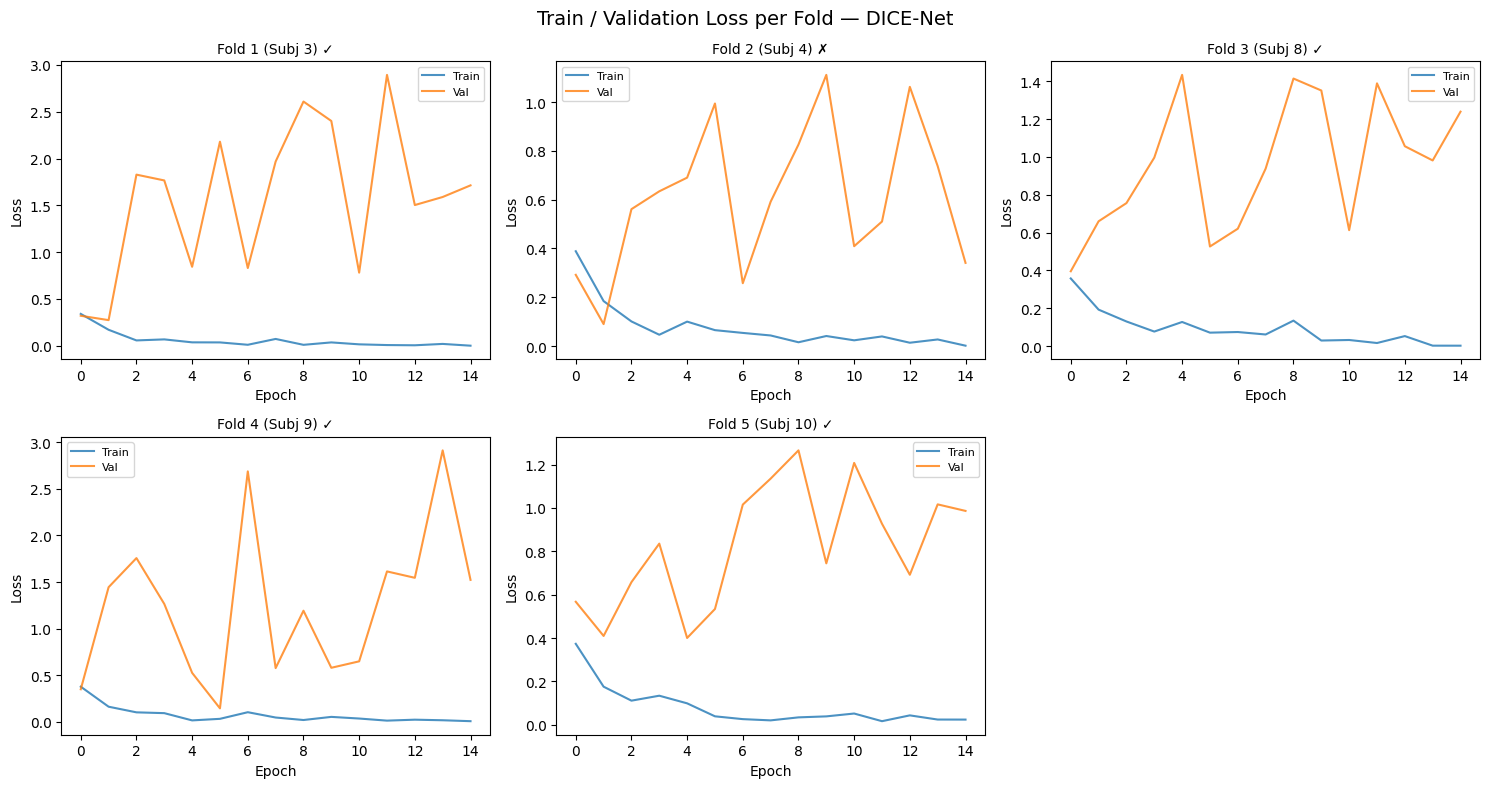

In [ ]:
# ----- Train / Validation Loss Curves (best model) -----
# Skip if best model has no loss curves (e.g. Random Forest)
has_losses = any(len(r.get('train_losses', [])) > 0 for r in loso_results)

if has_losses:
    n_plot = min(6, len(loso_results))
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for i in range(n_plot):
        ax = axes[i]
        r = loso_results[i]
        ax.plot(r['train_losses'], label='Train', alpha=0.8)
        ax.plot(r['val_losses'], label='Val', alpha=0.8)
        status = "✓" if r['avg_pred'] == r['true_label'] else "✗"
        ax.set_title(f"Fold {r['fold']+1} (Subj {r['test_subject']}) {status}", fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8)

    for i in range(n_plot, len(axes)):
        axes[i].set_visible(False)

    plt.suptitle(f'Train / Validation Loss per Fold — {best_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['RESULTS_DIR'], 'loss_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"Skipping loss curves — {best_name} is not a deep learning model.")

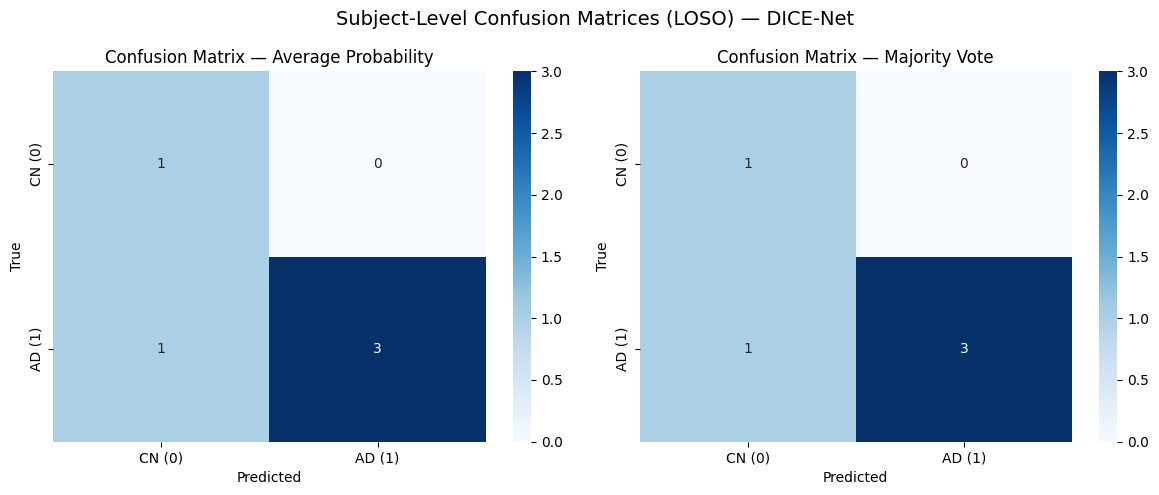

In [ ]:
# ----- Subject-Level Confusion Matrix -----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (method, true, preds, title) in zip(axes, [
    ('avg', avg_true, avg_preds, 'Average Probability'),
    ('maj', maj_true, maj_preds, 'Majority Vote'),
]):
    cm = confusion_matrix(true, preds, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['CN (0)', 'AD (1)'],
                yticklabels=['CN (0)', 'AD (1)'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — {title}')

plt.suptitle(f'Subject-Level Confusion Matrices (LOSO) — {best_name}', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['RESULTS_DIR'], 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()


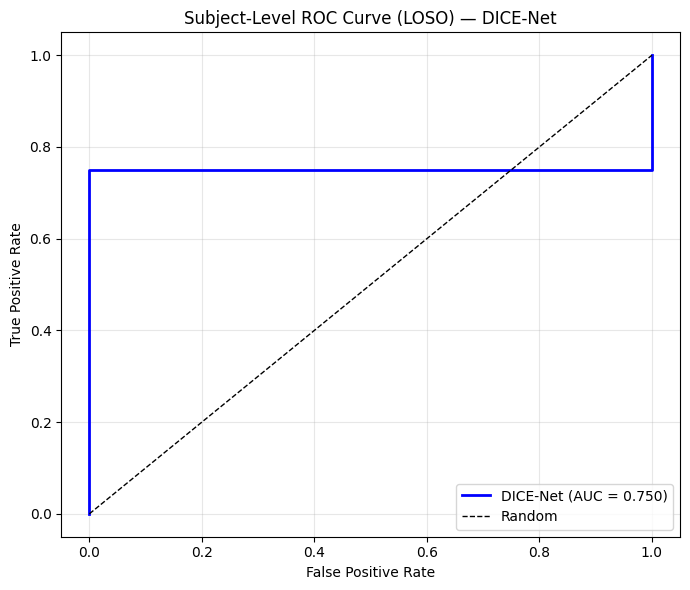

In [ ]:
# ----- ROC Curve -----
if len(set(avg_true)) > 1:
    fpr, tpr, thresholds = roc_curve(avg_true, avg_probs)
    auc_val = roc_auc_score(avg_true, avg_probs)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, 'b-', lw=2, label=f'{best_name} (AUC = {auc_val:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Subject-Level ROC Curve (LOSO) — {best_name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['RESULTS_DIR'], 'roc_curve.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Cannot plot ROC curve: only one class present in test results.")
    print("Run full LOSO to get both classes represented.")

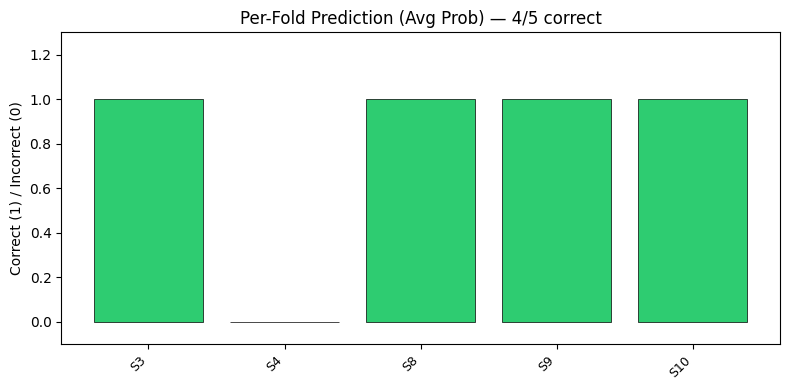

In [ ]:
# ----- Per-Fold Correctness Barplot -----
fig, ax = plt.subplots(figsize=(max(8, len(loso_results) * 0.5), 4))

fold_labels = [f"S{r['test_subject']}" for r in loso_results]
colors = ['#2ecc71' if c else '#e74c3c' for c in avg_correct]

ax.bar(range(len(loso_results)), avg_correct, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(loso_results)))
ax.set_xticklabels(fold_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Correct (1) / Incorrect (0)')
ax.set_title(f'Per-Fold Prediction (Avg Prob) — '
             f'{sum(avg_correct)}/{len(avg_correct)} correct')
ax.set_ylim(-0.1, 1.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['RESULTS_DIR'], 'fold_barplot.png'), dpi=150, bbox_inches='tight')
plt.show()


## 18. Save Results

In [ ]:
# Save model comparison table
comparison_path = os.path.join(CONFIG['RESULTS_DIR'], 'model_comparison.csv')
comparison_df.to_csv(comparison_path, index=False)
print(f"Model comparison saved to {comparison_path}")

# Save best model's fold results
results_path = os.path.join(CONFIG['RESULTS_DIR'], 'loso_results.csv')
fold_df.to_csv(results_path, index=False)
print(f"Fold results ({best_name}) saved to {results_path}")

# Save overall metrics
metrics_path = os.path.join(CONFIG['RESULTS_DIR'], 'overall_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f"Overall metrics saved to {metrics_path}")

# Save full results as numpy for later analysis
np.savez(
    os.path.join(CONFIG['RESULTS_DIR'], 'full_results.npz'),
    true_labels=avg_true,
    avg_preds=avg_preds,
    avg_probs=avg_probs,
    maj_preds=maj_preds,
)
print(f"Full results saved to {CONFIG['RESULTS_DIR']}")

print(f"\nCheckpoints saved in: {CONFIG['CHECKPOINT_DIR']}")
print(f"Total checkpoint files: {len(os.listdir(CONFIG['CHECKPOINT_DIR']))}")

Model comparison saved to ./training/results/model_comparison.csv
Fold results (DICE-Net) saved to ./training/results/loso_results.csv
Overall metrics saved to ./training/results/overall_metrics.csv
Full results saved to ./training/results

Checkpoints saved in: ./training/checkpoints
Total checkpoint files: 30


## 19. Inference Helper for Unseen Test Subjects

Use a trained fold model to predict on new EEG `.npy` files.

Two inference modes:
1. **Single model**: Use one fold's checkpoint
2. **Ensemble**: Average predictions across all fold models


In [ ]:
MODEL_CLASSES = {
    'DICE-Net': DICENet,
    'SimpleCNN': SimpleCNN,
    'BiLSTM': BiLSTMNet,
}

def predict_subject(npy_path, checkpoint_path, scaler_path, config, device, model_class=None):
    '''
    Predict AD vs CN for a single unseen subject using one fold's model.

    Args:
        npy_path: path to the subject's .npy EEG file
        checkpoint_path: path to fold checkpoint .pt file
        scaler_path: path to fold scalers .npz file
        config: CONFIG dict
        device: torch device
        model_class: nn.Module class (auto-detected from checkpoint if None)

    Returns:
        dict with prediction details
    '''
    # Extract features
    rbp, scc = extract_subject_features(
        npy_path, config['ORIG_SFREQ'], config['TARGET_SFREQ'],
        config['WINDOW_SEC'], config['OVERLAP_SEC']
    )

    # Load and apply scaler
    scalers = np.load(scaler_path)
    rbp = apply_scaler(rbp, scalers['rbp_mean'], scalers['rbp_std'])
    scc = apply_scaler(scc, scalers['scc_mean'], scalers['scc_std'])

    # Build dataset
    rbp_t = torch.tensor(rbp, dtype=torch.float32)
    scc_t = torch.tensor(scc, dtype=torch.float32)
    dummy_labels = torch.zeros(len(rbp_t), 1)
    ds = EEGFeatureDataset(rbp_t, scc_t, dummy_labels)
    loader = DataLoader(ds, batch_size=config['BATCH_SIZE'], shuffle=False)

    # Load model — auto-detect class from checkpoint if not specified
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    if model_class is None:
        saved_name = ckpt.get('model_name', 'DICE-Net')
        model_class = MODEL_CLASSES.get(saved_name, DICENet)
    model = model_class(config).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    # Predict
    all_probs = []
    with torch.no_grad():
        for r, s, _ in loader:
            r, s = r.to(device), s.to(device)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits = model(r, s)
            probs = torch.sigmoid(logits).cpu().squeeze(-1)
            all_probs.append(probs)

    all_probs = torch.cat(all_probs).numpy()
    avg_prob = all_probs.mean()
    avg_pred = int(avg_prob >= 0.5)
    maj_pred = int((all_probs >= 0.5).mean() >= 0.5)

    return {
        'avg_prob': float(avg_prob),
        'avg_pred': avg_pred,
        'maj_pred': maj_pred,
        'n_windows': len(all_probs),
        'window_probs': all_probs.tolist(),
    }


def predict_subject_ensemble(npy_path, config, device, model_name='DICE-Net', n_folds=None):
    '''
    Ensemble prediction: average predictions across all available fold models.
    '''
    ckpt_dir = config['CHECKPOINT_DIR']
    safe_name = model_name.replace(' ', '_')
    model_class = MODEL_CLASSES.get(model_name, DICENet)

    if n_folds is None:
        fold_files = sorted([f for f in os.listdir(ckpt_dir)
                             if f.startswith(f'{safe_name}_fold_') and f.endswith('_best.pt')])
        n_folds = len(fold_files)

    all_avg_probs = []
    for fold_idx in range(n_folds):
        ckpt_path = os.path.join(ckpt_dir, f'{safe_name}_fold_{fold_idx}_best.pt')
        scaler_path = os.path.join(ckpt_dir, f'{safe_name}_fold_{fold_idx}_scalers.npz')
        if not os.path.exists(ckpt_path) or not os.path.exists(scaler_path):
            continue
        result = predict_subject(npy_path, ckpt_path, scaler_path, config, device,
                                 model_class=model_class)
        all_avg_probs.append(result['avg_prob'])

    if len(all_avg_probs) == 0:
        raise ValueError(f"No fold checkpoints found for {model_name}.")

    ensemble_prob = np.mean(all_avg_probs)
    return {
        'ensemble_prob': float(ensemble_prob),
        'ensemble_pred': int(ensemble_prob >= 0.5),
        'n_models': len(all_avg_probs),
        'per_fold_probs': all_avg_probs,
    }

print("Inference helpers defined.")

Inference helpers defined.


In [ ]:
# Example: predict on unlabeled subjects using the best model's fold 0
if len(unlabeled_files) > 0:
    safe_best = best_name.replace(' ', '_')
    print(f"Found {len(unlabeled_files)} unlabeled .npy files.")
    print(f"Predicting with {best_name} fold 0 model...\n")

    ckpt_path = os.path.join(CONFIG['CHECKPOINT_DIR'], f'{safe_best}_fold_0_best.pt')
    scaler_path = os.path.join(CONFIG['CHECKPOINT_DIR'], f'{safe_best}_fold_0_scalers.npz')

    if os.path.exists(ckpt_path) and os.path.exists(scaler_path):
        inference_results = []
        for sid in sorted(unlabeled_files.keys()):
            try:
                result = predict_subject(
                    unlabeled_files[sid], ckpt_path, scaler_path, CONFIG, device
                )
                result['subject_id'] = sid
                inference_results.append(result)
                pred_label = "AD" if result['avg_pred'] == 1 else "CN"
                print(f"  Subject {sid:3d}: {pred_label} "
                      f"(prob={result['avg_prob']*100:.1f}%, windows={result['n_windows']})")
            except Exception as e:
                print(f"  Subject {sid:3d}: ERROR — {e}")

        if inference_results:
            inf_df = pd.DataFrame(inference_results)[
                ['subject_id', 'avg_prob', 'avg_pred', 'maj_pred', 'n_windows']]
            inf_df.to_csv(os.path.join(CONFIG['RESULTS_DIR'], 'test_predictions.csv'), index=False)
            print(f"\nTest predictions saved to {CONFIG['RESULTS_DIR']}/test_predictions.csv")
    else:
        print("No checkpoints available yet. Run training first.")
else:
    print("No unlabeled subjects found.")

Found 15 unlabeled .npy files.
Predicting with DICE-Net fold 0 model...

  Subject   5: CN (prob=10.9%, windows=12)
  Subject   6: CN (prob=19.3%, windows=12)
  Subject  17: CN (prob=14.3%, windows=12)
  Subject  20: CN (prob=9.0%, windows=14)
  Subject  22: CN (prob=10.5%, windows=11)
  Subject  25: AD (prob=77.4%, windows=12)
  Subject  26: CN (prob=38.0%, windows=14)
  Subject  33: CN (prob=26.6%, windows=12)
  Subject  35: CN (prob=5.8%, windows=15)
  Subject  36: CN (prob=3.9%, windows=12)
  Subject  45: CN (prob=4.2%, windows=12)
  Subject  47: CN (prob=22.4%, windows=11)
  Subject  60: CN (prob=21.8%, windows=12)
  Subject  67: AD (prob=61.0%, windows=11)
  Subject  87: CN (prob=4.1%, windows=13)

Test predictions saved to ./training/results/test_predictions.csv


## 20. Final Notes

### How to Run This on Google Colab

1. Go to [colab.google.com](https://colab.google.com) → **File → Upload notebook** → pick this `.ipynb`.
2. **Runtime → Change runtime type → GPU** (T4 free tier is fine).
3. Upload your data via the **Files panel** (folder icon on the left):
   - Upload `AD/` folder (25 `.npy` files) → must end up at `/content/AD/`
   - Upload `CN/` folder (28 `.npy` files) → must end up at `/content/CN/`
   - Upload `train_label_mapping.csv` → must end up at `/content/train_label_mapping.csv`
4. **Runtime → Run all**.
5. Smoke test runs first (`QUICK_SMOKE_TEST = True`) — trains all 4 models on 5 folds.
6. Once it passes, set `QUICK_SMOKE_TEST = False` and re-run for the full 53-fold LOSO.

**Note:** Files uploaded to `/content/` are lost when the runtime disconnects. Re-upload if you restart.

### Models Compared

| Model | Type | Description |
|-------|------|-------------|
| **DICE-Net** | Conv + Transformer | Dual-branch: separate Conv1D + Transformer for RBP and SCC |
| **SimpleCNN** | Conv1D | Single-branch: concatenated RBP+SCC → 3-layer Conv1D |
| **BiLSTM** | Recurrent | Bidirectional LSTM on concatenated features |
| **Random Forest** | Classical ML | sklearn RF on flattened RBP+SCC (200 trees, balanced weights) |

### Methodology Summary

| Aspect | Approach |
|--------|----------|
| Features | RBP + SCC (5 frequency bands × 19 channels) |
| Windows | 30s windows, 15s overlap, downsampled to 128 Hz |
| Evaluation | Leave-One-Subject-Out (LOSO) — no data leakage |
| Inner validation | ~20% of training subjects per fold |
| Aggregation | Average probability + majority vote |
| Normalization | StandardScaler fit on training fold only |
| Imbalance handling | Weighted BCE loss (DL) / balanced class weights (RF) |
| Results | All metrics shown as percentages |